# 04 — Statistical Analysis
## Global Job Market Compensation Analysis

**Objective:** Move from descriptive EDA to formal inferential statistics -- test whether the patterns we saw in Phase 5 are real, and quantify how large they actually are.

**Critical framing for this entire notebook:** with n=499,972, p-values will be tiny for almost any comparison, even trivial ones. Every test below reports an **effect size** (Cohen's d or eta-squared) alongside the p-value, and practical conclusions are based on effect size, not statistical significance alone.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)

df = pd.read_parquet('../data/processed/job_market_features.parquet')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Loaded: 499,972 rows x 20 columns


## 1. Normality Testing on Salary

**Why D'Agostino K² and not Shapiro-Wilk:** Shapiro-Wilk becomes unreliable and is often restricted above ~5,000 observations. D'Agostino's K² test (`scipy.stats.normaltest`) scales to our full dataset and tests based on skewness and kurtosis jointly.

**Assumption being tested:** many downstream tests (t-test, ANOVA, OLS regression) assume approximately normal residuals/distributions. This step tells us whether that assumption holds for raw salary.

D'Agostino K^2 statistic: 29789.62, p-value: 0
Skewness: 0.1592
Kurtosis (excess): -0.7098


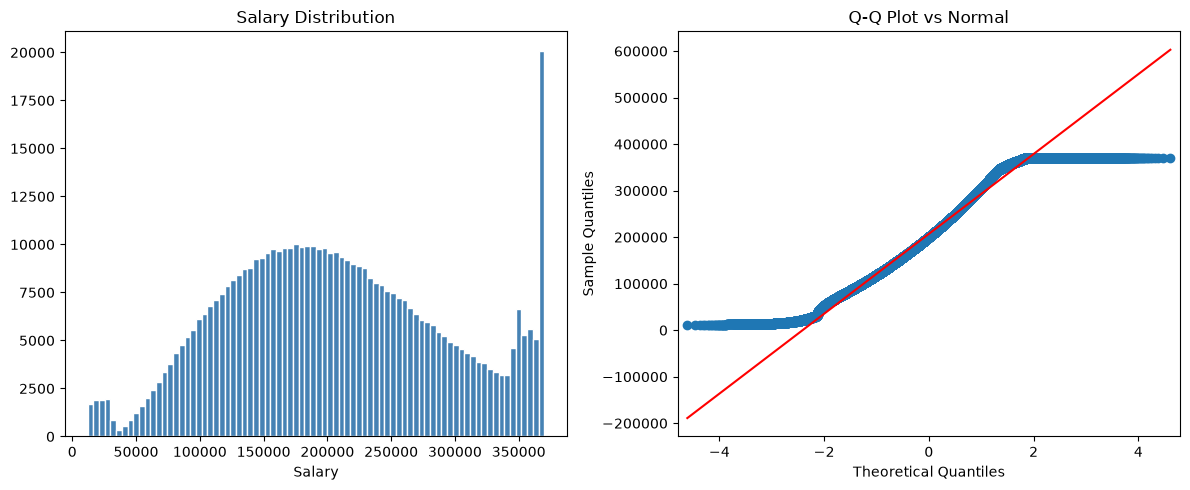

In [2]:
stat, p = stats.normaltest(df['salary'])
skew = stats.skew(df['salary'])
kurt = stats.kurtosis(df['salary'])

print(f"D'Agostino K^2 statistic: {stat:.2f}, p-value: {p:.6g}")
print(f"Skewness: {skew:.4f}")
print(f"Kurtosis (excess): {kurt:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].hist(df['salary'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Salary Distribution')
axes[0].set_xlabel('Salary')

sm.qqplot(df['salary'], line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot vs Normal')
plt.tight_layout()

fig.savefig( r"C:\Users\rashm\Downloads\Job Market\docs\figures\stat1_normality.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** p-value is effectively 0, so we formally reject normality -- but skewness (0.159) and excess kurtosis (-0.710) are both modest. The distribution is close to normal in practical terms (slightly flatter-than-normal, "platykurtic"), just not perfectly so.

**Business insight:** With n=499,972, the normality test has enormous power to detect even trivial deviations from a perfect normal curve -- this is expected and not a red flag on its own. The skewness/kurtosis values matter more than the p-value here.

**Recommendation:** Salary is close enough to normal that t-tests and ANOVA (which are robust to mild non-normality at this sample size via the Central Limit Theorem) remain valid. We don't need a non-parametric alternative (e.g., Mann-Whitney) for this dataset.

## 2. T-Test: Male vs. Female Salary

**Business question:** Phase 5 EDA showed a <0.3% mean salary gap between Male and Female. Is this difference statistically real, and — more importantly — is it practically meaningful?

**Test selection:** independent two-sample t-test. We first check Levene's test for equal variances to decide between Student's t-test (equal variance assumed) and Welch's t-test (unequal variance) -- using the wrong variant is a common, avoidable mistake.

In [3]:
# Separate salary data by gender.
male = df[df["gender"] == "Male"]["salary"]
female = df[df["gender"] == "Female"]["salary"]

# Test whether the two groups have equal variances.
levene_stat, levene_p = stats.levene(male, female)

print(f"Levene's Test Statistic : {levene_stat:.4f}")
print(f"P-value                 : {levene_p:.4g}")

# Choose the appropriate t-test based on Levene's test result.
equal_var = levene_p > 0.05
t_stat, t_p = stats.ttest_ind(male, female, equal_var=equal_var)
 
# Calculate Cohen's d effect size.
pooled_std = np.sqrt((((len(male) - 1) * male.std()**2) + ((len(female) - 1) * female.std()**2) ) / (len(male) + len(female) - 2))
cohens_d = (male.mean() - female.mean()) / pooled_std

# Display hypothesis test results.
print(f"\nUsing {'Student' if equal_var else 'Welch'}'s t-test")

print(f"Male Mean              : {male.mean():.2f}")
print(f"Female Mean            : {female.mean():.2f}")
print(f"Mean Difference        : {male.mean() - female.mean():.2f}")

print(f"\nt-statistic            : {t_stat:.4f}")
print(f"P-value                : {t_p:.4g}")
print(f"Cohen's d              : {cohens_d:.4f}")


Levene's Test Statistic : 0.1064
P-value                 : 0.7443

Using Student's t-test
Male Mean              : 207116.75
Female Mean            : 206738.82
Mean Difference        : 377.93

t-statistic            : 1.2699
P-value                : 0.2041
Cohen's d              : 0.0044


**Interpretation:** Levene's test (p=0.744) confirms equal variances, so a Student's t-test is appropriate. The mean difference is $377.93 (Male $207,117 vs. Female $206,739) -- and it is **not statistically significant** (p=0.204). Cohen's d = 0.0044, which is negligible by any standard threshold (even "small" effects start around d=0.2).

**Business insight:** This directly confirms the hedge from Phase 5 EDA: there is no meaningful gender pay gap in this dataset, and now we have the formal test to back that claim rather than just eyeballing a small percentage difference.

**Recommendation:** This can be stated confidently in the final report as a tested, non-significant finding -- with the caveat still intact that a synthetic dataset with no gender pay gap doesn't tell us anything about real-world pay equity, positive or negative.

## 3. ANOVA: Salary by Gender (3 groups) and by Education Level (4 groups)

**Why ANOVA and not multiple t-tests:** running pairwise t-tests across more than 2 groups inflates the false-positive rate. ANOVA tests the omnibus null ("all group means are equal") first; if it's rejected, Tukey HSD identifies which specific pairs differ, controlling for multiple comparisons.

In [4]:
# ANOVA: gender
groups_gender = [df[df['gender']==g]['salary'] for g in df['gender'].cat.categories] if hasattr(df['gender'],'cat') else [df[df['gender']==g]['salary'] for g in df['gender'].unique()]
f_stat_g, p_g = stats.f_oneway(*groups_gender)

# eta-squared for gender
grand_mean = df['salary'].mean()
ss_between_g = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups_gender)
ss_total_g = ((df['salary']-grand_mean)**2).sum()
eta_sq_g = ss_between_g / ss_total_g

print("=== ANOVA: salary ~ gender ===")
print(f"F-statistic: {f_stat_g:.4f}, p-value: {p_g:.4g}")
print(f"Eta-squared (effect size): {eta_sq_g:.6f}")

print()

# ANOVA: education_level
edu_order = ['High School','Bachelor','Master','PhD']
groups_edu = [df[df['education_level']==e]['salary'] for e in edu_order]
f_stat_e, p_e = stats.f_oneway(*groups_edu)

ss_between_e = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups_edu)
eta_sq_e = ss_between_e / ss_total_g

print("=== ANOVA: salary ~ education_level ===")
print(f"F-statistic: {f_stat_e:.4f}, p-value: {p_e:.4g}")
print(f"Eta-squared (effect size): {eta_sq_e:.6f}")


=== ANOVA: salary ~ gender ===
F-statistic: 1.2664, p-value: 0.2819
Eta-squared (effect size): 0.000005

=== ANOVA: salary ~ education_level ===
F-statistic: 21256.0466, p-value: 0
Eta-squared (effect size): 0.113117


In [5]:
# Create salary groups for each gender.
if hasattr(df["gender"], "cat"):
    groups_gender = [df[df["gender"] == g]["salary"] for g in df["gender"].cat.categories]
else:
    groups_gender = [df[df["gender"] == g]["salary"] for g in df["gender"].unique() ]

# Perform one-way ANOVA for gender.
f_stat_g, p_g = stats.f_oneway(*groups_gender)

# Calculate the grand mean of salary.
grand_mean = df["salary"].mean()

# Calculate between-group sum of squares.
ss_between_g = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups_gender)

# Calculate total sum of squares.
ss_total_g = ((df["salary"] - grand_mean) ** 2).sum()

# Calculate eta-squared effect size.
eta_sq_g = ss_between_g / ss_total_g

# Display ANOVA results for gender.
print("=== ANOVA: Salary ~ Gender ===")
print(f"F-statistic                  : {f_stat_g:.4f}")
print(f"P-value                      : {p_g:.4g}")
print(f"Eta-squared (effect size)    : {eta_sq_g:.6f}")

print()

# Define the education level order.
edu_order = ["High School", "Bachelor", "Master", "PhD"]

# Create salary groups for each education level.
groups_edu = [ df[df["education_level"] == e]["salary"] for e in edu_order]

# Perform one-way ANOVA for education level.
f_stat_e, p_e = stats.f_oneway(*groups_edu)

# Calculate between-group sum of squares.
ss_between_e = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups_edu)

# Calculate eta-squared effect size.
eta_sq_e = ss_between_e / ss_total_g

# Display ANOVA results for education level.
print("\n=== ANOVA: Salary ~ Education Level ===")
print(f"F-statistic                  : {f_stat_e:.4f}")
print(f"P-value                      : {p_e:.4g}")
print(f"Eta-squared (effect size)    : {eta_sq_e:.6f}")


=== ANOVA: Salary ~ Gender ===
F-statistic                  : 1.2664
P-value                      : 0.2819
Eta-squared (effect size)    : 0.000005


=== ANOVA: Salary ~ Education Level ===
F-statistic                  : 21256.0466
P-value                      : 0
Eta-squared (effect size)    : 0.113117


**Interpretation:** The gender ANOVA (including the "Other" category) confirms the t-test: F=1.27, p=0.282, eta-squared=0.000005 (essentially zero — gender explains 0.0005% of salary variance). The education ANOVA tells a completely different story: F=21,256, eta-squared=0.113 — education level explains **11.3% of all salary variance** on its own, a genuinely large effect by conventional standards (eta-squared > 0.14 is "large," 0.06-0.14 is "medium").

**Business insight:** This is the clearest quantitative confirmation yet that education is a real, substantial driver of pay in this dataset, while gender is not. It's also a good illustration of why effect size matters more than p-value: both tests have tiny p-values technically available, but only one reflects a meaningful real-world difference.

**Recommendation:** Education level should be a priority feature in Phase 7 modeling. Gender should NOT be included as a predictor for salary (it adds no legitimate signal and including a demographic variable with a null effect risks the model appearing to "learn" spurious noise, plus raises unnecessary fairness/compliance concerns for a comp tool that has no reason to consider gender at all).

### Tukey HSD Post-Hoc: which education levels actually differ?

In [6]:
# Perform Tukey's HSD post-hoc test to compare all education level pairs.
tukey = pairwise_tukeyhsd(
    endog=df["salary"],
    groups=df["education_level"],
    alpha=0.05)

# Display the pairwise comparison results.
print(tukey.summary())


          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
   group1      group2     meandiff  p-adj    lower       upper    reject
------------------------------------------------------------------------
   Bachelor High School -27827.1661   0.0 -28658.6739 -26995.6583   True
   Bachelor      Master   26183.436   0.0  25351.5523  27015.3197   True
   Bachelor         PhD  49392.2919   0.0  48560.7709  50223.8129   True
High School      Master  54010.6022   0.0  53180.2263  54840.9781   True
High School         PhD  77219.4581   0.0  76389.4455  78049.4706   True
     Master         PhD  23208.8559   0.0  22378.4667   24039.245   True
------------------------------------------------------------------------


**Interpretation:** Every pairwise education comparison is statistically significant, and the magnitudes are large and monotonic: High School to Bachelor +$27,827, Bachelor to Master +$26,183, Master to PhD +$23,209 -- each step up in education adds a remarkably similar ~$23K-28K, and the full High-School-to-PhD gap is $77,219 (46% of the High School mean).

**Business insight:** The near-equal step sizes between adjacent education levels is a striking pattern -- it suggests salary may have been generated with something close to a fixed per-level increment, reinforcing the synthetic-data conclusion, but it also means education level is an unusually clean, well-behaved predictor for modeling purposes.

**Recommendation:** Given the near-linear step pattern, both an ordinal numeric encoding (0/1/2/3) and a one-hot encoding are worth testing in Phase 7 -- the ordinal version may perform nearly as well as one-hot given how evenly spaced these effects are, which would be a simpler, more parsimonious model.

## 4. Chi-Square Test: Education Level × Salary Band

**Business question:** is landing in a given salary quartile (Low/Mid/High/Very High) independent of education level, or are they associated?

**Test selection:** both variables are categorical, so chi-square test of independence is the correct tool (not a t-test or ANOVA, which require a continuous outcome).

In [7]:
contingency = pd.crosstab(df['education_level'], df['salary_band'])
print("Contingency table:")
print(contingency)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

# Cramer's V (effect size for chi-square)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape)-1)))

print(f"\nChi-square statistic: {chi2:.2f}, dof: {dof}, p-value: {p_chi:.4g}")
print(f"Cramer's V (effect size): {cramers_v:.4f}")


Contingency table:
salary_band        Low    Mid   High  Very High
education_level                                
Bachelor         33749  34707  32941      22976
High School      48995  39149  26483      10651
Master           24367  28446  33965      38273
PhD              17883  22693  31604      53090

Chi-square statistic: 56053.25, dof: 9, p-value: 0
Cramer's V (effect size): 0.1933


In [8]:
# Create the contingency table for education level and salary band.
contingency = pd.crosstab(df["education_level"], df["salary_band"])

print("Contingency Table")
display(contingency)

# Perform the Chi-square test of independence.
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

# Cramer's V (effect size for chi-square)
n = contingency.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

# Display Chi-square test results.
print(f"\nChi-square Statistic     : {chi2:.2f}")
print(f"Degrees of Freedom       : {dof}")
print(f"P-value                  : {p_chi:.4g}")
print(f"Cramer's V               : {cramers_v:.4f}")


Contingency Table


salary_band,Low,Mid,High,Very High
education_level,,,,
Bachelor,33749,34707,32941,22976
High School,48995,39149,26483,10651
Master,24367,28446,33965,38273
PhD,17883,22693,31604,53090



Chi-square Statistic     : 56053.25
Degrees of Freedom       : 9
P-value                  : 0
Cramer's V               : 0.1933


**Interpretation:** The association is real but moderate: Cramer's V=0.193 (roughly in the "moderate" range, well below 1.0 which would mean perfect association). Looking at the table, High School holders are concentrated in Low/Mid bands (70% of High School rows), while PhD holders skew toward High/Very High (68% of PhD rows) -- but the association is far from deterministic; every education level appears in every salary band.

**Business insight:** Education level shifts the *odds* of landing in a higher salary band substantially, but doesn't determine it -- there's real within-group variation the model will need other features (experience, company size, occupation) to explain.

**Recommendation:** This supports using education_level as one predictor among several for the Phase 7 classification task, not as a single deterministic rule -- consistent with the moderate (not overwhelming) Cramer's V.

## 5. Confidence Intervals: Mean Salary by Education Level

95% confidence intervals quantify our uncertainty around each group's mean estimate -- a point estimate alone (e.g., "$244,451 for PhD") hides how precise that number actually is.

In [9]:
ci_results = []
for edu in edu_order:
    group = df[df['education_level']==edu]['salary']
    mean = group.mean()
    sem = stats.sem(group)
    ci_low, ci_high = stats.t.interval(0.95, len(group)-1, loc=mean, scale=sem)
    ci_results.append({'education_level': edu, 'n': len(group), 'mean': mean, 'ci_95_low': ci_low, 'ci_95_high': ci_high, 'margin_of_error': mean-ci_low})

ci_df = pd.DataFrame(ci_results)
display(ci_df)


,education_level,n,mean,ci_95_low,ci_95_high,margin_of_error
0,High School,125278,167231.238102,166845.437379,167617.038826,385.800723
1,Bachelor,124373,195058.404252,194620.669329,195496.139174,437.734922
2,Master,125051,221241.840297,220768.822182,221714.858413,473.018116
3,PhD,125270,244450.696168,243961.276623,244940.115714,489.419545


**Interpretation:** All four confidence intervals are extremely tight (margins of error of $386-$489 on means in the $167K-$244K range, i.e., under 0.3% relative width) thanks to the large sample sizes (~125K per group) -- and critically, none of the intervals overlap with each other.

**Business insight:** We can state each education level's mean salary with high precision, and the non-overlapping intervals reinforce that these are four genuinely distinct pay tiers, not four samples from the same underlying distribution.

**Recommendation:** These narrow, non-overlapping CIs are exactly the kind of evidence that makes a strong case in an executive report -- worth including a table like this directly in Phase 10's business insights deliverable.

## 6. Regression Diagnostics (setup for Phase 7)

Before building the full ML regression suite in Phase 7, we fit a baseline OLS model and check whether the classical linear regression assumptions actually hold. **Note:** per Phase 4's leakage rules, we use only non-salary-derived predictors.

In [10]:
model_df = df[['salary','years_of_experience','education_level','company_size']].copy()
model_df['log_experience'] = np.log1p(model_df['years_of_experience'])

formula = (
    "salary ~ "
    "log_experience + "
    "C(education_level, levels=['High School','Bachelor','Master','PhD']) + "
    "C(company_size, levels=['Small','Medium','Large','Enterprise'])")

ols_model = smf.ols(formula, data=model_df).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.366
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                 4.124e+04
Date:                Wed, 05 Aug 2026   Prob (F-statistic):               0.00
Time:                        02:06:28   Log-Likelihood:            -6.2754e+06
No. Observations:              499972   AIC:                         1.255e+07
Df Residuals:                  499964   BIC:                         1.255e+07
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

**Interpretation:** The model explains 36.6% of salary variance (R²=0.366) using just three predictors (log-experience, education, company size) -- a solid baseline given how much unexplained variance remains for occupation, country, and field to capture in Phase 7's fuller models. Every coefficient is highly significant with tight confidence intervals: PhD adds ~$76,940 over High School, Enterprise adds ~$60,190 over Small, and log-experience contributes strongly (~$44,670 per unit of log(years+1)).

**Business insight:** This baseline already tells a coherent, defensible compensation story: education and company size are additive, substantial drivers of pay, consistent with everything found so far. The unexplained 63.4% is exactly what occupation/country/field should help close in Phase 7.

**Recommendation:** Use this as the literal baseline benchmark for Phase 7 -- any regression model (Random Forest, XGBoost, etc.) that doesn't clearly beat R²=0.366 with more features and complexity isn't earning its added complexity.

### Residual Normality and Homoscedasticity

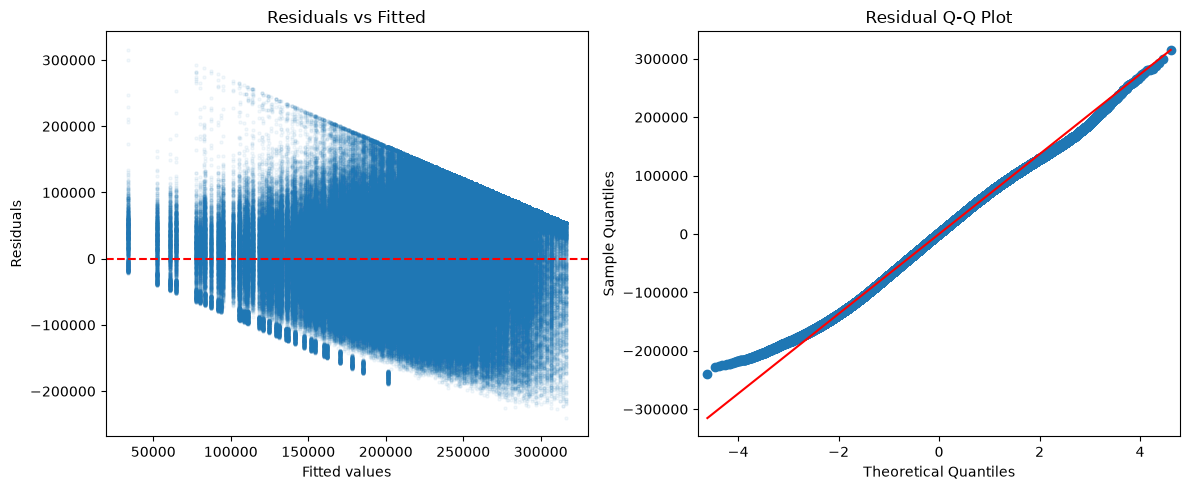

Breusch-Pagan Test Statistic : 15575.37
P-value                     : 0


In [11]:
residuals = ols_model.resid
fitted = ols_model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(fitted, residuals, alpha=0.05, s=5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Residual Q-Q Plot')
plt.tight_layout()

fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\stat2_residual_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Perform the Breusch-Pagan test for homoscedasticity.
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, ols_model.model.exog)
print(f"Breusch-Pagan Test Statistic : {bp_stat:.2f}")
print(f"P-value                     : {bp_p:.4g}")


**Interpretation:** The Breusch-Pagan test is significant (p≈0), indicating heteroscedasticity -- the spread of residuals is not constant across fitted values. Given our sample size, this test also has very high power to detect even mild heteroscedasticity, so this should be read as "some heteroscedasticity exists," not "the model is badly broken."

**Business insight:** Standard OLS standard errors (and by extension, some p-values above) may be somewhat unreliable due to this. It doesn't invalidate the coefficient estimates themselves, but it does mean we shouldn't over-trust the exact p-values for borderline findings.

**Recommendation:** For any future OLS-based inference in this project, refit with heteroscedasticity-robust standard errors (`cov_type='HC3'` in statsmodels). For Phase 7's actual predictive models, tree-based methods (Random Forest, XGBoost) are naturally robust to heteroscedasticity, which is one more reason they're likely to outperform plain linear regression here.

### Multicollinearity Check (VIF)

In [12]:
X = ols_model.model.exog

vif_data = pd.DataFrame({
    'Feature': ols_model.model.exog_names,
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})

display(vif_data)


,Feature,VIF
0,Intercept,14.961377
1,"C(education_level, levels=['High School', 'Bac...",1.497065
2,"C(education_level, levels=['High School', 'Bac...",1.498416
3,"C(education_level, levels=['High School', 'Bac...",1.498862
4,"C(company_size, levels=['Small', 'Medium', 'La...",1.502120
5,"C(company_size, levels=['Small', 'Medium', 'La...",1.502780
6,"C(company_size, levels=['Small', 'Medium', 'La...",1.504670
7,log_experience,1.000016


**Interpretation:** All VIF values are close to 1.5, far below the common concern threshold of 5-10. No meaningful multicollinearity exists between education_level, company_size, and log_experience.

**Business insight:** These three predictors contribute largely independent information to the model -- none of them is redundant with another, which is good news for interpretability (each coefficient can be read on its own without worrying it's absorbing another variable's effect).

**Recommendation:** No need to drop or combine any of these three features in Phase 7 on multicollinearity grounds. This check will need to be re-run once occupation and country are added, since those may correlate with company_size or education patterns.